# 05 — Excessive-Returner Anomaly Detection

**Purpose:** Model 2. Identify customers with statistically aberrant return patterns
using Isolation Forest. Compare to Local Outlier Factor. Validate against return rate ranking.

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import mlflow

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (12, 5), 'figure.dpi': 110,
    'axes.facecolor': '#1a1d27', 'figure.facecolor': '#0f1117',
    'axes.edgecolor': '#2e3347', 'axes.labelcolor': '#e8eaf0',
    'xtick.color': '#8b92a8', 'ytick.color': '#8b92a8',
    'text.color': '#e8eaf0', 'grid.color': '#2e3347', 'grid.alpha': 0.5,
})

from src.models import train_anomaly_detector, predict_anomaly

mlflow.set_tracking_uri('../mlflow/mlruns')
mlflow.set_experiment('retail-returns-intelligence')
print('Setup OK')

Setup OK


In [2]:
customer_features = pd.read_parquet('../data/processed/customer_features.parquet')

# Numeric columns for anomaly detection
anomaly_cols = [c for c in customer_features.columns
                if c not in ('customer_id',) and customer_features[c].dtype in (float, int)
                and customer_features[c].notnull().all()]

# Fill any remaining NaN with column median
X_anomaly = customer_features[anomaly_cols].fillna(customer_features[anomaly_cols].median())

print(f'Customers: {len(X_anomaly):,}')
print(f'Anomaly features: {anomaly_cols}')
print(X_anomaly.describe().round(3).to_string())

Customers: 5,881
Anomaly features: ['total_orders', 'total_revenue', 'unique_categories_purchased', 'total_return_orders', 'total_return_value', 'unique_categories_returned', 'n_weekend_returns', 'lifetime_return_rate', 'return_value_ratio', 'weekend_return_share', 'tenure_days', 'recency_score', 'frequency_score', 'monetary_score', 'return_velocity']
       total_orders  total_revenue  unique_categories_purchased  total_return_orders  total_return_value  unique_categories_returned  n_weekend_returns  lifetime_return_rate  return_value_ratio  weekend_return_share  tenure_days  recency_score  frequency_score  monetary_score  return_velocity
count      5881.000       5881.000                     5881.000             5881.000            5881.000                    5881.000           5881.000              5881.000            5881.000              5881.000     5881.000       5881.000         5881.000        5881.000         5881.000
mean          6.287       3017.077                       8

## 1. Isolation Forest

In [3]:
with mlflow.start_run(run_name='isolation-forest'):
    mlflow.log_params({'contamination': 0.05, 'n_estimators': 100})
    iforest, scaler_if = train_anomaly_detector(X_anomaly, contamination=0.05)
    anomaly_results = predict_anomaly(iforest, scaler_if, X_anomaly)
    n_flagged = anomaly_results['anomaly_flag'].sum()
    flag_rate = n_flagged / len(anomaly_results)
    mlflow.log_metrics({'n_flagged': int(n_flagged), 'flag_rate': flag_rate})

print(f'Flagged as excessive returners: {n_flagged:,} ({flag_rate:.1%})')
print(anomaly_results.head())

Flagged as excessive returners: 294 (5.0%)
   anomaly_score  anomaly_flag
0      -0.141365             1
1       0.155811             0
2       0.182593             0
3       0.164774             0
4       0.188735             0


## 2. Compare to LOF

In [4]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

scaler_lof = StandardScaler()
X_scaled = scaler_lof.fit_transform(X_anomaly)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_preds = lof.fit_predict(X_scaled)
lof_flags = (lof_preds == -1).astype(int)

n_lof = lof_flags.sum()
overlap = ((anomaly_results['anomaly_flag'] == 1) & (lof_flags == 1)).sum()

print(f'Isolation Forest flagged: {n_flagged:,}')
print(f'LOF flagged:              {n_lof:,}')
print(f'Agreement (both flag):    {overlap:,} ({overlap/n_flagged:.1%} of IF flags)')

Isolation Forest flagged: 294
LOF flagged:              294
Agreement (both flag):    89 (30.3% of IF flags)


## 3. Anomaly score distribution

Median return rate — Normal: 0.00% | Flagged: 34.43%


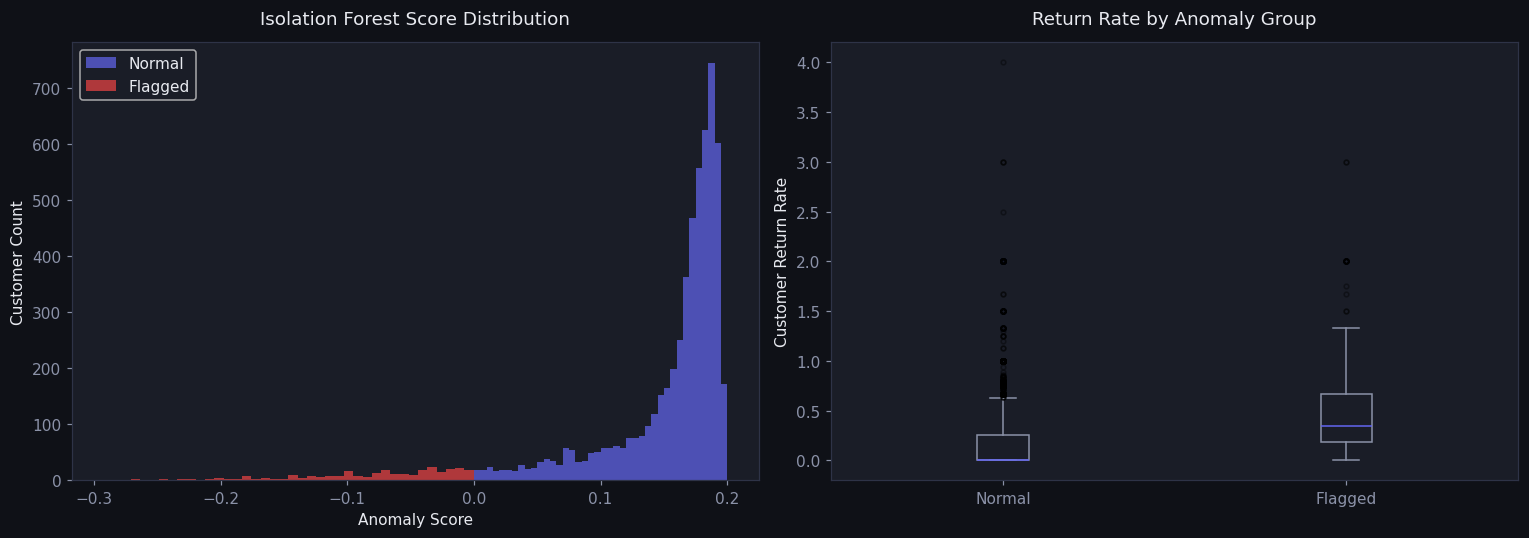

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
normal_scores  = anomaly_results.loc[anomaly_results['anomaly_flag']==0, 'anomaly_score']
flagged_scores = anomaly_results.loc[anomaly_results['anomaly_flag']==1, 'anomaly_score']

axes[0].hist(normal_scores,  bins=40, color='#6366f1', alpha=0.7, label='Normal')
axes[0].hist(flagged_scores, bins=40, color='#ef4444', alpha=0.7, label='Flagged')
axes[0].set_xlabel('Anomaly Score'); axes[0].set_ylabel('Customer Count')
axes[0].set_title('Isolation Forest Score Distribution', pad=12)
axes[0].legend()

# Attach anomaly results to customer features for validation
df_val = customer_features.copy().reset_index(drop=True)
df_val['anomaly_flag'] = anomaly_results['anomaly_flag'].values
df_val['anomaly_score'] = anomaly_results['anomaly_score'].values

# Compare return-related metrics by flag group
if 'lifetime_return_rate' in df_val.columns:
    rr_col = 'lifetime_return_rate'
elif 'return_rate' in df_val.columns:
    rr_col = 'return_rate'
elif 'cust_return_rate' in df_val.columns:
    rr_col = 'cust_return_rate'
else:
    # Fallback: derive from available columns
    rr_col = None

if rr_col:
    flagged_rr = df_val.loc[df_val['anomaly_flag']==1, rr_col]
    normal_rr  = df_val.loc[df_val['anomaly_flag']==0, rr_col]
    axes[1].boxplot([normal_rr.dropna(), flagged_rr.dropna()],
                    labels=['Normal', 'Flagged'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#1a1d27', color='#8b92a8'),
                    medianprops=dict(color='#6366f1'),
                    whiskerprops=dict(color='#8b92a8'),
                    capprops=dict(color='#8b92a8'),
                    flierprops=dict(marker='.', color='#ef4444', alpha=0.4))
    axes[1].set_ylabel('Customer Return Rate'); axes[1].set_title('Return Rate by Anomaly Group', pad=12)
    print(f'Median return rate — Normal: {normal_rr.median():.2%} | Flagged: {flagged_rr.median():.2%}')
else:
    axes[1].text(0.5, 0.5, 'return_rate column\nnot found', ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/05_anomaly_scores.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 4. Save model and flagged customers

In [6]:
os.makedirs('../models', exist_ok=True)
joblib.dump(iforest,  '../models/anomaly_detector.joblib')
joblib.dump(scaler_if,'../models/anomaly_scaler.joblib')

# Persist flagged-customer list for downstream notebooks
flagged_customers = df_val[df_val['anomaly_flag']==1][['customer_id', 'anomaly_score']]
flagged_customers.to_parquet('../data/processed/flagged_customers.parquet', index=False)

print(f'Saved: anomaly_detector.joblib, anomaly_scaler.joblib')
print(f'Saved: flagged_customers.parquet ({len(flagged_customers):,} rows)')
print('\nTop 10 most anomalous customers:')
print(df_val.nsmallest(10, 'anomaly_score')[['customer_id','anomaly_score']].to_string(index=False))

Saved: anomaly_detector.joblib, anomaly_scaler.joblib
Saved: flagged_customers.parquet (294 rows)

Top 10 most anomalous customers:
customer_id  anomaly_score
    14911.0      -0.292587
    14156.0      -0.283137
    12748.0      -0.271613
    15311.0      -0.269980
    17841.0      -0.268893
    14606.0      -0.255431
    13798.0      -0.245745
    14527.0      -0.242875
    13694.0      -0.241671
    13081.0      -0.236442
